Laboratorio 3, Fisica Computacional

Juan Manuel Patiño Daza

In [1]:
import numpy as np
import pandas as pd
import time as tm
import matplotlib.pyplot as plt
from numba import njit

## Problema 1

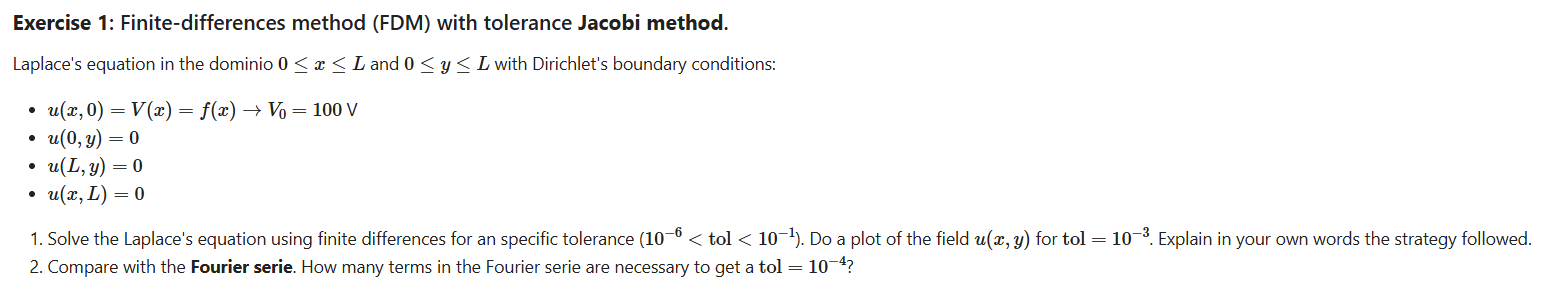

In [2]:
@njit  #este decorador solamente va a hacer que no esperemos mas de 2 segundos al ejecutar estas funciones
def Laplace2D_FDM(V_ini,Niter):
  'Int the V initial configutaration.\n Niter is the number of the iterations of the algorithm. Return V_out Laplace case.'

  Nmax = V_ini.shape[0]
  V = V_ini.copy()
  conv = np.zeros((100, 100), float)

  iter = 0

  while iter <= Niter:
    iter+=1
    for i in range(1, Nmax-1):
      for j in range(1,Nmax-1):
        conv[i,j] = V[i+1,j]+V[i-1,j]+V[i,j+1]+V[i,j-1] - 4*V[i,j]
        V[i,j] = 0.25*(V[i+1,j]+V[i-1,j]+V[i,j+1]+V[i,j-1])


    if np.max(np.abs(conv)) <= 1e-4:
      print(iter)
      print(np.max(conv))
      break

  return V

In [3]:
def grid(V_ini,x,y):
  'to compute x,y,z'
  V = V_ini.copy()
  X, Y = np.meshgrid(x,y)
  Z = V[X,Y] #filed value
  return X,Y,Z

7323
9.990062017095624e-05
time (s)= 0.5100017290000007


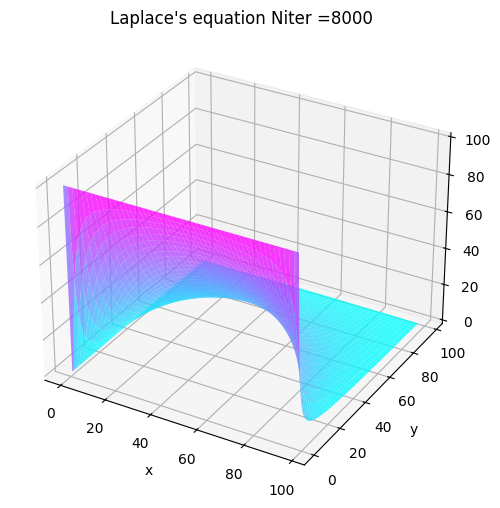

In [17]:
Nmax, Niter = 100, 8000

# Initial V matrix
V_ini = np.zeros((Nmax, Nmax), float)
for k in range(0, Nmax):
  V_ini[k,0] = 100

# Do the grid to plot
x = np.arange(0, Nmax-1, 1)
y = x

# propagate signal
start = tm.process_time() # Starting time counter for user
# Run Laplace2D rutine
V = Laplace2D_FDM(V_ini, Niter)
X,Y,Z = grid(V,x,y)
end = tm.process_time() # Finishing time counter for user
print('time (s)=' ,end-start )

# Plot the field
fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection='3d')
ax.plot_surface(X, Y, Z, cmap='cool', alpha=0.8)
ax.set_title('Laplace\'s equation Niter =%.1d'%Niter)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.show()

1. Metodo de diferencias finitas:

en este caso hacemos uso del algoritmo visto en clase usando diferencias finitas, exeptuando que agregamos unas lineas para obtener la tolerancia, en este caso medimos la tolerancia usando los valores de la grilla actualizados menos el punto de referencia es decir, antes de calcular el valor de V[i,j], sumamos los aportes de los 4 vecinos de V[i,j] con los valores actualizados y les restamos 4 veces V[i,j], si el aporte de los vecinos es mas pequeño que la tolerancia entonces paramos el ciclo while antes, se calcula con el valor previo de V porque si actualizamos el valor y luego calculamos entonces eso seria un 0 rotundo


In [5]:
#Define the n-esimo modo
def un(x,y,n=1,L=1):
  'function to compute the n-esimo term of the Fouriers serie'
  v0 = 100 #Voltage
  return (4*v0/(n*np.pi))*np.sin(n*np.pi*x/L)*np.sinh(n*np.pi*(L-y)/L)/np.sinh(n*np.pi)

In [6]:
#Making the grid to do the plot
L = 1 # Longitude
coordx = np.linspace(0,L,100) # 100 puntos
coordy = coordx
x , y = np.meshgrid(coordx, coordy, indexing= 'ij')

101


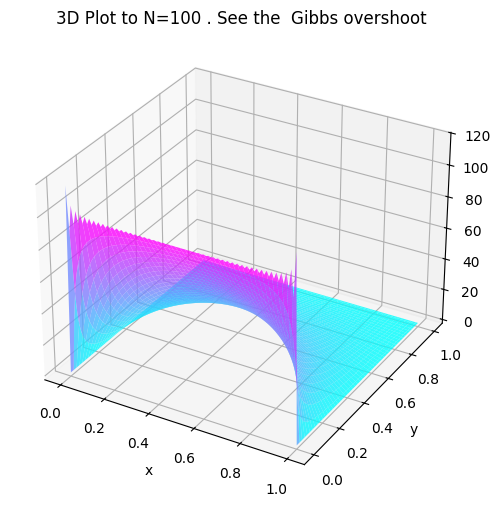

In [7]:
#Plot to N-1 frecuencies
N = 200
z = 0
tol = 1e-4

n=1
z_old = np.zeros([100,100])
while n <= N:
  z += un(x,y,n,L)
  n += 2
  if np.max(np.abs(z_old - z)) < tol:
    print(n)
    break
  else:
    z_old = z.copy()

fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection='3d')
ax.plot_surface(x, y, z, cmap='cool', alpha=0.8)
ax.set_title('3D Plot to N=%.1d . See the  Gibbs overshoot'%(n-1))
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.show()

2. Metodo de furier:
- en este caso el metodo de furier es mas dificil calcular la tolerancia porque todas las soluciones N-esimas son soluciones al problema, en este caso hacemos uso de la convergencia de la serie, es decir cuando un termino aporta menos que la tolerancia que queremos entonces dejamos de usar esos terminos.

- en 101 terminos termina la serie pero aun se nota el error de gibs

## Problema 2

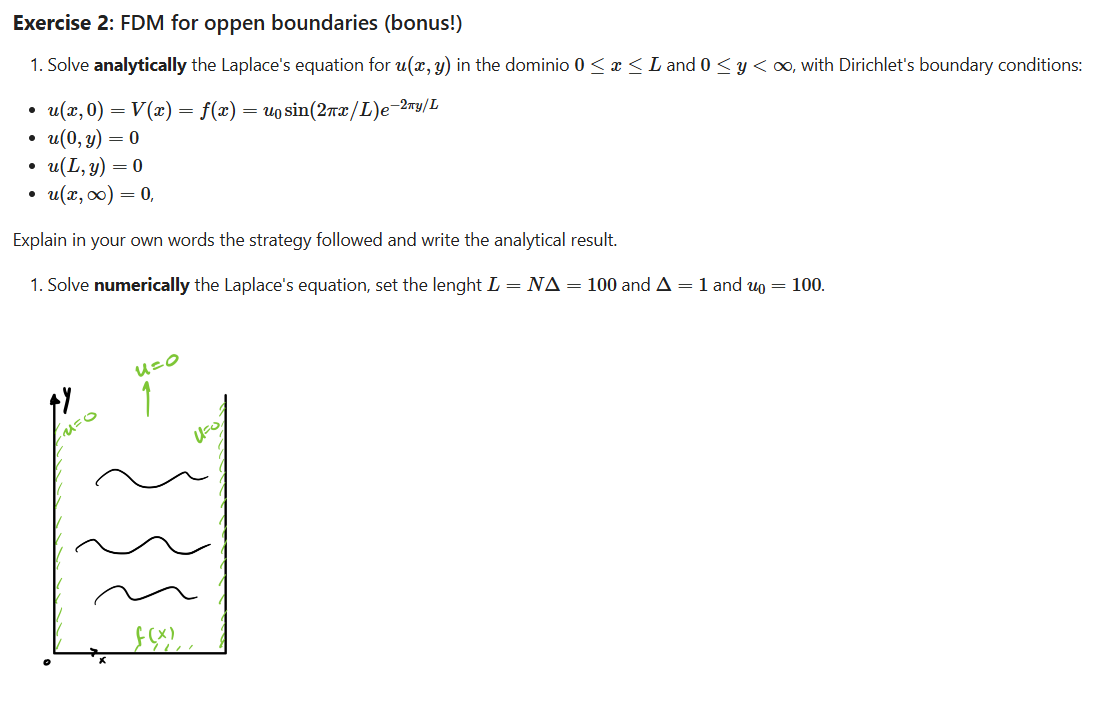

Resolviendo la ecuacion diferencial de forma analitica obtuve la siguiente funcion

$$u_{\text{exacta}} = u_0 \sin\left(\frac{2\pi X}{L}\right) \exp\left(-\frac{2\pi Y}{L}\right)$$


para llegar a esta solucion se uso el metodo de separacion de variables y posterior se aplico las condiciones de frontera

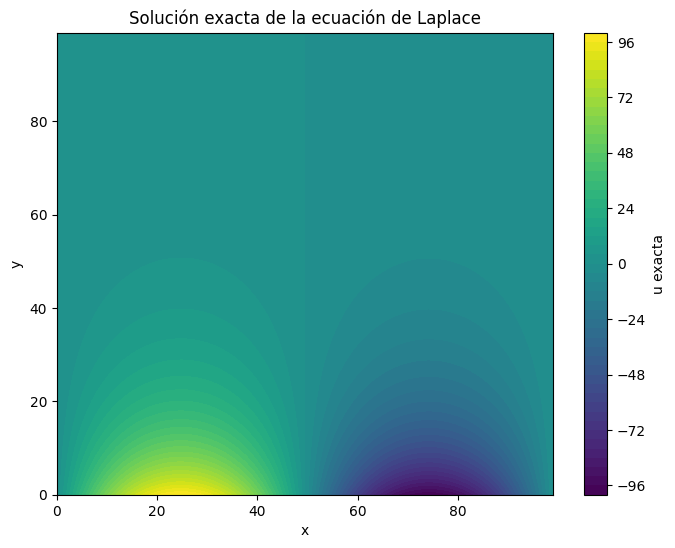

In [8]:
u0 = 100
L=99
delta = 1

x = np.arange(0,L+delta,1)
y = np.arange(0,L+delta,1)
X, Y = np.meshgrid(x, y)

u_exacta = (u0 * np.sin(2*np.pi*X/L) * np.exp(-2*np.pi*Y/L))

plt.figure(figsize=(8,6))

plt.contourf(X, Y, u_exacta, levels=50)

plt.colorbar(label="u exacta")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Solución exacta de la ecuación de Laplace")
plt.show()

2934
9.983999870044613e-05
time (s)= 0.14885118499999983


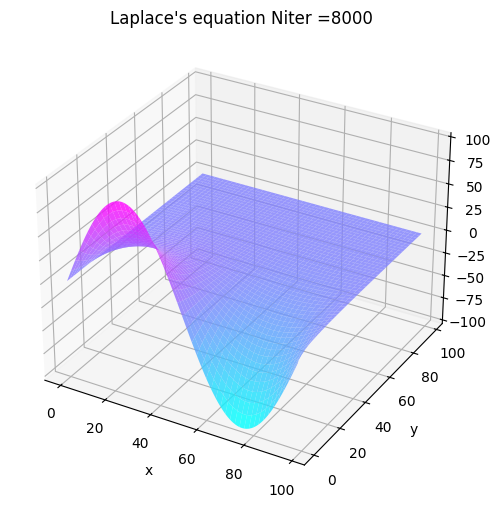

In [9]:
Nmax, Niter = 100, 8000
L=100
delta = 1
u0=100

# Initial V matrix
V_ini = np.zeros((Nmax, Nmax), float)
for k in range(0, Nmax,1):
  V_ini[k,0] = u0 * np.sin(2*k*np.pi/L) #en este caso el piso es una funcion y no una cte

# Do the grid to plot
x = np.arange(0, Nmax-1, 1)
y = x

# propagate signal
start = tm.process_time() # Starting time counter for user
# Run Laplace2D rutine
V = Laplace2D_FDM(V_ini, Niter)
X,Y,Z = grid(V,x,y)
end = tm.process_time() # Finishing time counter for user
print('time (s)=' ,end-start )

# Plot the field
fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection='3d')
ax.plot_surface(X, Y, Z, cmap='cool', alpha=0.8)
ax.set_title('Laplace\'s equation Niter =%.1d'%Niter)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.show()

Solucion numerica:
- la solucion numerica simplmente es el metodo de visto en clase modificando que la parte inferior pasa de ser una costante a ser una funcion de las x en este caso K

In [10]:
# Invertimos los ejes de la analítica para alinearlos con V
u_exactaT = u_exacta.T

# Cálculo del error global
error = np.abs(V - u_exactaT)

print("Error máximo:", error.max())

Error máximo: 6.279051952931391


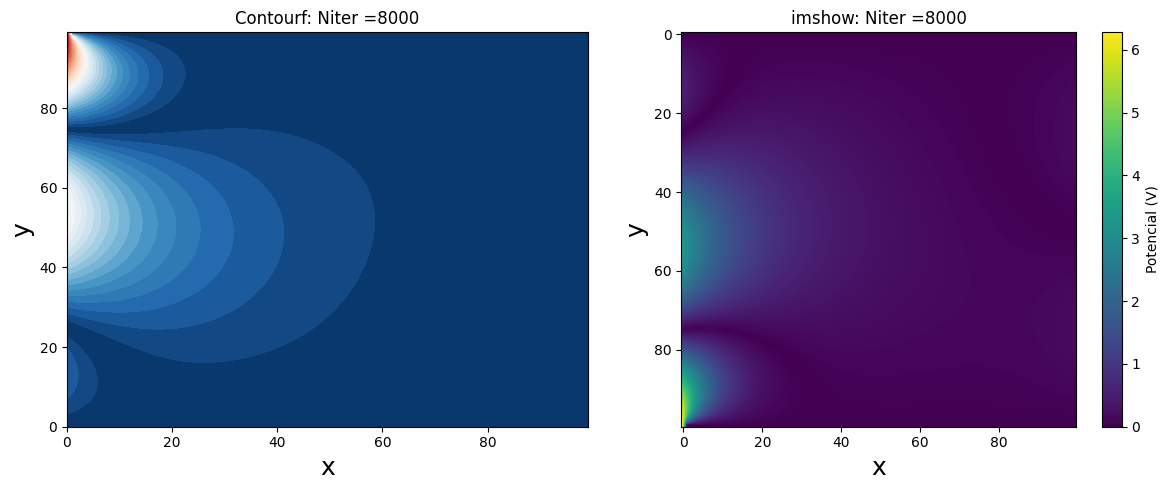

In [11]:
# Crear figura
fig = plt.figure(figsize=(12,5))

# 🔹 Subplot 1: Superficie 3D
ax1 = fig.add_subplot(1,2,1)
ax1.contourf(error,levels = 40, cmap='RdBu_r')
ax1.set_title('Contourf: Niter =%.1d'%Niter)
ax1.set_xlabel("x",size=18)
ax1.set_ylabel("y",size=18)

# 🔹 Subplot 2: Campo eléctrico 2D
ax2 = fig.add_subplot(1,2,2)
im = ax2.imshow(error.copy(), interpolation="bilinear", ) # cmap="hot"


ax2.set_title('imshow: Niter =%.1d'%Niter)
ax2.set_xlabel("x",size=18)
ax2.set_ylabel("y",size=18)

# Barra de color (solo una, asociada al potencial)
fig.colorbar(im, ax=ax2, label='Potencial (V)')


plt.tight_layout()
plt.show()

resultados:

en este caso vemos que el la mayor fuente de error se encuentra sobre el eje Y, donde deveriamos encontrar un valor de 0, es decir que uno de los 2 metodos tiene error en encontrar los valores correspondientes en la frontera, tiendo como error maximo: 6.279051

## Problema 3

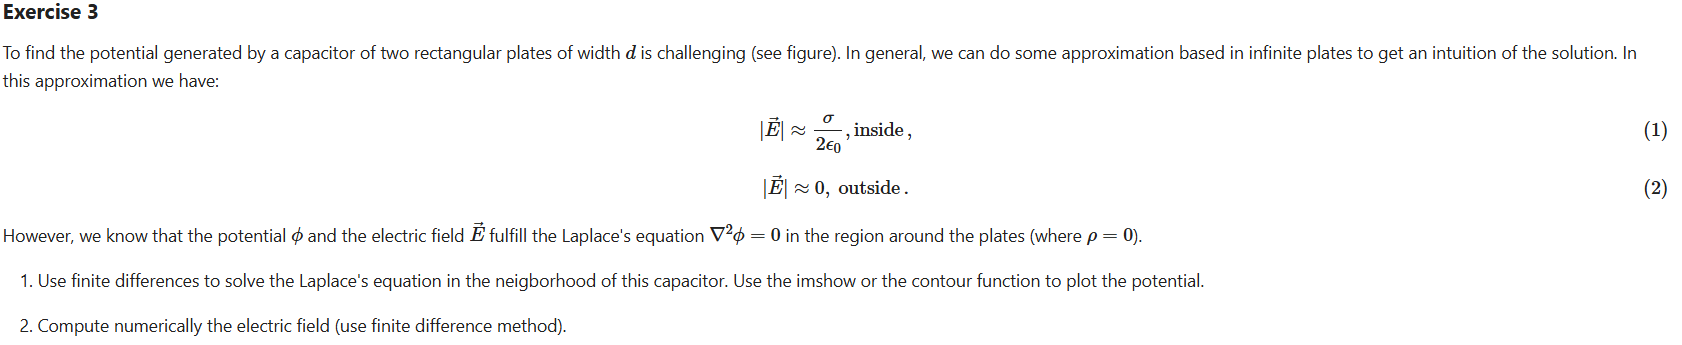

In [12]:
@njit
def Laplace2D_FDM(V_ini,Niter):
  'Int the V initial configutaration.\n Niter is the number of the iterations of the algorithm. Return V_out Laplace case.'

  Nmax = V_ini.shape[0]
  V = V_ini.copy()
  conv = np.zeros((100, 100), float)

  iter = 0

  placas = (V_ini==50) | (V_ini==-50)  #placas es una matrix con True o False, donde solamente
                                       #tiene True en las pociciones donde hay un potencial de 50 o -50

  while iter <= Niter:
    iter+=1
    for i in range(1, Nmax-1):
      for j in range(1,Nmax-1):
        if placas[i,j]== True: #esto es para asegurarnos que no actualize los valores de las placas de los capacitores
          continue
        else:
          conv[i,j] = V[i+1,j]+V[i-1,j]+V[i,j+1]+V[i,j-1] - 4*V[i,j]
          V[i,j] = 0.25*(V[i+1,j]+V[i-1,j]+V[i,j+1]+V[i,j-1])


    if np.max(np.abs(conv)) <= 1e-4:
      print(iter)
      print(np.max(conv))
      break

  return V

In [13]:
def grid(V_ini,x,y):
  'to compute x,y,z'
  V = V_ini.copy()
  X, Y = np.meshgrid(x,y)
  Z = V[X,Y] #filed value
  return X,Y,Z

2405
9.986753579482865e-05
time (s)= 0.5350802689999998


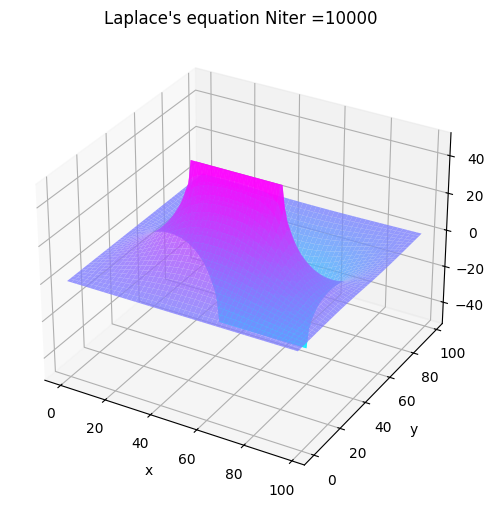

In [14]:
Nmax, Niter = 100, 10000
d = 20
l = 40

h = int((100-l)/2)
k = int((100-d)/2)

# Initial V matrix
V_ini = np.zeros((Nmax, Nmax), float)
for i in range(h, h+l):
  V_ini[i,k] = 50
  V_ini[i,k+d] = -50

# Do the grid to plot
x = np.arange(0, Nmax-1, 1)
y = x

# propagate signal
start = tm.process_time() # Starting time counter for user
# Run Laplace2D rutine
V = Laplace2D_FDM(V_ini, Niter)
X,Y,Z = grid(V,x,y)
end = tm.process_time() # Finishing time counter for user
print('time (s)=' ,end-start )

# Plot the field
fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection='3d')
ax.plot_surface(X, Y, Z, cmap='cool', alpha=0.8)
ax.set_title('Laplace\'s equation Niter =%.1d'%Niter)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.show()

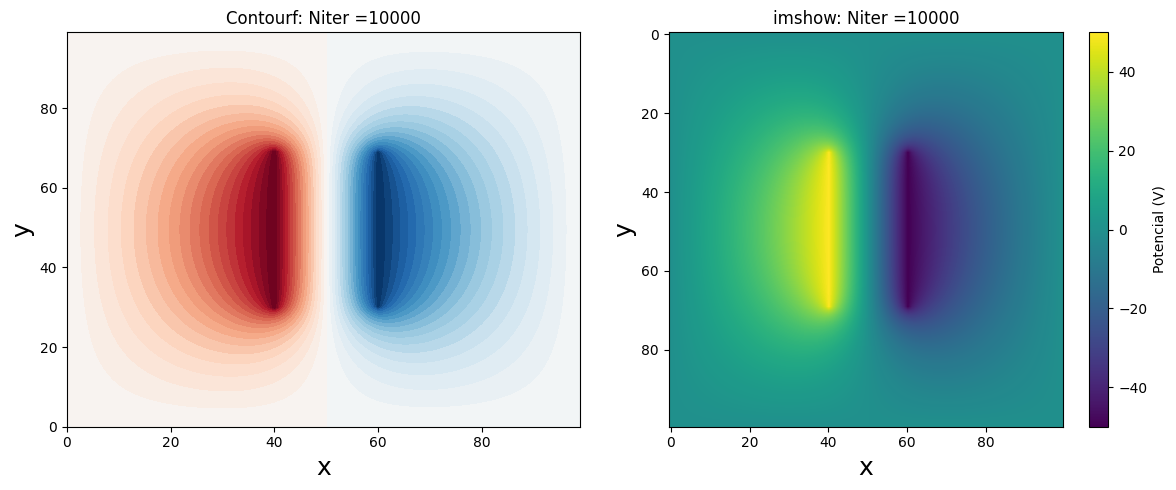

In [15]:
# Crear figura
fig = plt.figure(figsize=(12,5))

# 🔹 Subplot 1: Superficie 3D
ax1 = fig.add_subplot(1,2,1)
ax1.contourf(V,levels = 40, cmap='RdBu_r')
ax1.set_title('Contourf: Niter =%.1d'%Niter)
ax1.set_xlabel("x",size=18)
ax1.set_ylabel("y",size=18)

# 🔹 Subplot 2: Campo eléctrico 2D
ax2 = fig.add_subplot(1,2,2)
im = ax2.imshow(V.copy(), interpolation="bilinear", ) # cmap="hot"


ax2.set_title('imshow: Niter =%.1d'%Niter)
ax2.set_xlabel("x",size=18)
ax2.set_ylabel("y",size=18)

# Barra de color (solo una, asociada al potencial)
fig.colorbar(im, ax=ax2, label='Potencial (V)')


plt.tight_layout()
plt.show()

**diferencias finitas en el capacitor**

- la forma de abordar este problema fue con una grilla de ceros exeptuando los puntos donde estan las placas.

- se puso un condicional que si se va a modificar el valor de un elemento donde esta un punto de una placa este no se modifique, puesto que las placas van a mantener su valor inicial, recordando que este metodo modifica toda la grilla menos los bordes entonces las placas sin este condicional estan sujetas a modificacion de sus valores.

- del punto 1 se hereda la forma en la que calculamos la tolerancia

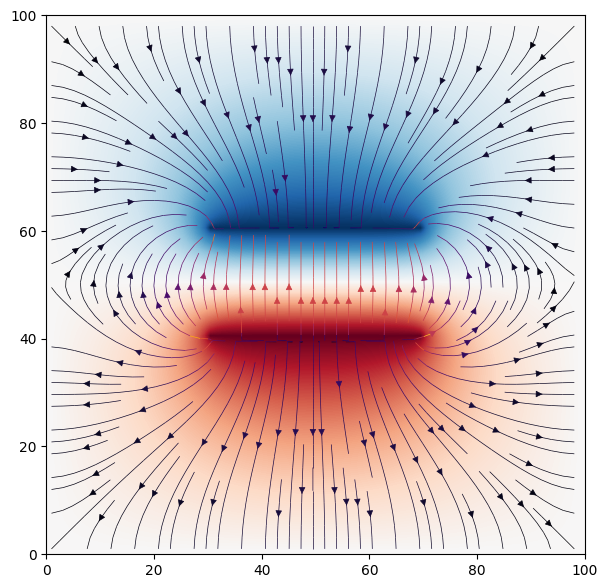

In [16]:
U = V.copy()

err = 1e-5
d = 10
l = 20
volt = 50
Nx = 100
Ny = 100
# GRID PARAMETERS
d_grid = d*Nx/100
l_grid = l*Ny/100

# Central derivative for E field
E = -np.stack([
    (U[2:, 1:-1] - U[0:-2, 1:-1]) / 2,
    (U[1:-1, 2:] - U[1:-1, 0:-2]) / 2,
], axis=-1)

Ex = E[..., 0]
Ey = E[..., 1]

x = np.arange(1, Nx-1)
y = np.arange(1, Ny-1)
X, Y = np.meshgrid(x, y, indexing='ij')

fig, ax = plt.subplots(figsize=(7, 7))

# Background: potential
#ax.imshow(U.T, interpolation="bilinear", extent=[0, Nx, 0, Ny])
ax.imshow(U.T, origin='lower', cmap='RdBu_r', extent=[0, Nx, 0, Ny],interpolation="bilinear")

# Streamlines, colored by field magnitude
magnitude = np.sqrt(Ex**2 + Ey**2)
ax.streamplot(X.T, Y.T, Ex.T, Ey.T,
                color = magnitude.T, cmap = 'inferno',
                density=1.5, linewidth=0.5)

ax.set_aspect('equal')
plt.show()